# __Notebook Exhibition__

## __EDA and Data Preprocessing Procedures:__

In [ ]:
# Import Packages:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os, time, random, pathlib, PIL

from PIL import Image
from pathlib import Path
from typing import Optional, Tuple, List

from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, Input, Sequential
from tensorflow.keras.applications.efficientnet import EfficientNetB3, preprocess_input
from tensorflow.keras.layers import Dense, RandomZoom, RandomFlip, RandomContrast, RandomBrightness
from sklearn.metrics import classification_report, f1_score, accuracy_score

### <u>__EDA - Performed on the Training Folder:__


In [5]:
# Review the number of classes:
train_dir = root/'train'
classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print("Number of classes (yoga poses):", len(classes))
print("Sample classes:", classes[:10])

Number of classes (yoga poses): 107
Sample classes: ['adho mukha svanasana', 'adho mukha vriksasana', 'agnistambhasana', 'ananda balasana', 'anantasana', 'anjaneyasana', 'ardha bhekasana', 'ardha chandrasana', 'ardha matsyendrasana', 'ardha pincha mayurasana']


Total images: 4150
Class with max count: 62
Class with min count: 12
Average count: 39.0


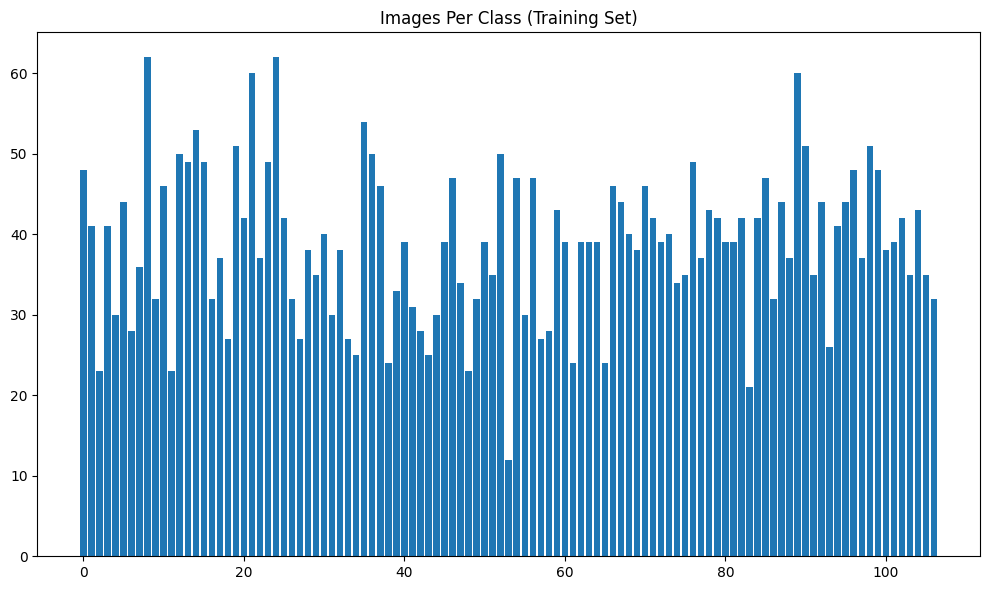

In [ ]:
# Count images in each class:
counts = {c: len(list((train_dir/c).glob("*"))) for c in classes}
class_counts = [len(list(folder.glob("*"))) for folder in train_dir.iterdir() if folder.is_dir()]

# General descriptive statistics of class counts:
print("Total images:", sum(counts.values()))
max_class = np.max(class_counts)
min_class = np.min(class_counts)
avg_class = np.mean(class_counts)
print("Class with max count:", max_class)
print("Class with min count:", min_class)
print("Average count:", avg_class.round(0))

# Plot images per class:
plt.figure(figsize=(10,6)); plt.bar(range(len(classes)), [counts[c] for c in classes]); plt.title("Images Per Class (Training Set)"); plt.tight_layout(); plt.show()

Sample image stats - first 10 images: [['PngImageFile', 'RGB', dtype('uint8'), (352, 502, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (203, 643, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (202, 586, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (355, 868, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (408, 483, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (153, 413, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (211, 484, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (268, 583, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (180, 344, 3)], ['PngImageFile', 'RGB', dtype('uint8'), (170, 337, 3)]]


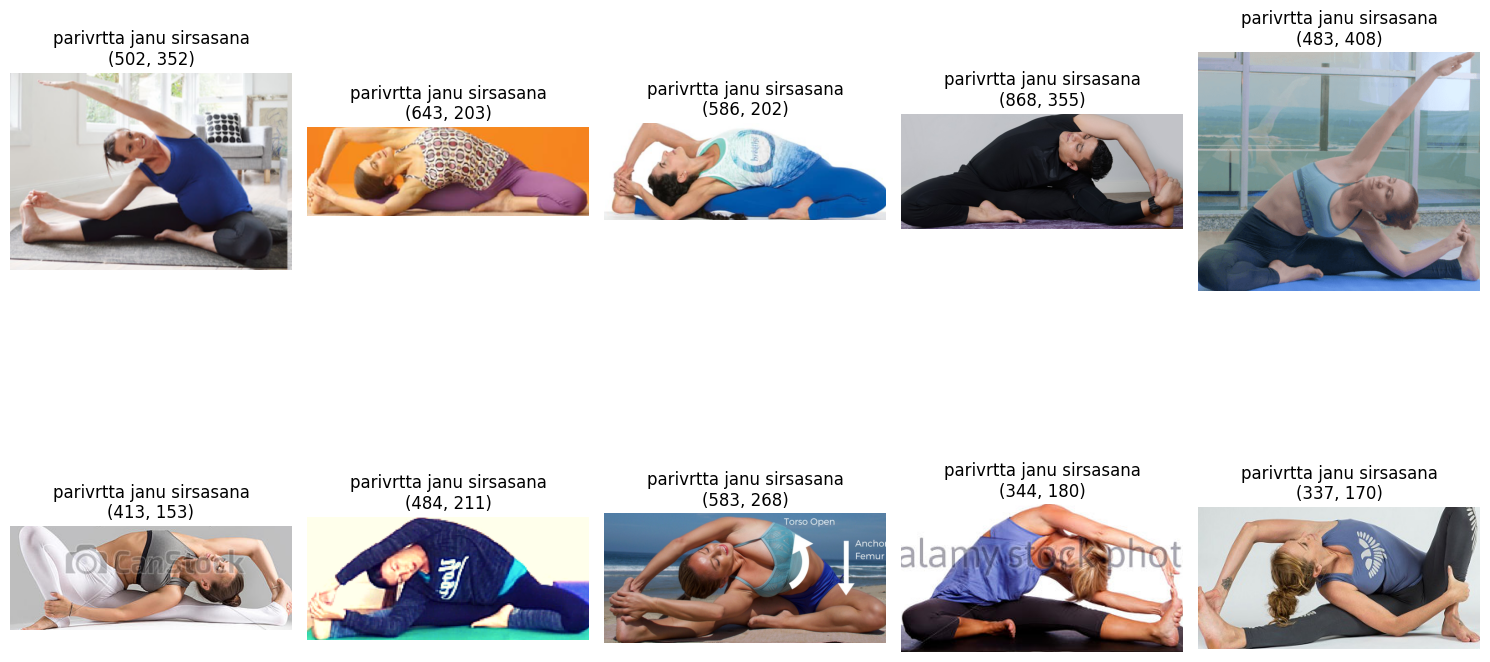

In [ ]:
# Check the image sizes (width, height) of sampled random images from up to 10 classes:
sizes = []
sampled_images = []
image_stats = []

for c in random.sample(classes, min(10, len(classes))):
    image_paths = list((train_dir / c).glob("*"))

    for p in random.sample(image_paths, min(10, len(image_paths))):
        try:
            with PIL.Image.open(p) as im:
                sizes.append(im.size)
                sampled_images.append((p, im.copy()))

                arr = np.array(im)
                image_stats.append([
                    type(im).__name__,
                    im.mode,
                    arr.dtype,
                    # Shape: (H, W, C):
                    arr.shape
                ])
        except:
            pass
print("Sample image stats - first 10 images:", image_stats[:10])

# Display the sampled images:
num_images_to_display = min(10, len(sampled_images))
plt.figure(figsize=(15, 10))

for i in range(num_images_to_display):
    path, image = sampled_images[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(f"{path.parent.name}\n{image.size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
all_rgb = True
non_rgb_images = []

for c in classes:
    image_paths = list((train_dir / c).glob("*"))
    for p in image_paths:
        try:
            with PIL.Image.open(p) as im:
                if im.mode != 'RGB':
                    all_rgb = False
                    non_rgb_images.append((p, im.mode))
        except:
            pass

if all_rgb:
    print("All images are in RGB mode.")
else:
    print(f"Found {len(non_rgb_images)} non-RGB images.")
    print("Examples:")
    for img, mode in non_rgb_images[:10]:
        print(f"{img}: mode - {mode}\n")

Found 249 non-RGB images.
Examples:
/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/35. 068155f5a8d0310c34a6ed06cb089294.png: mode - RGBA

/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/4. adho-mukha-svanasana-downward-dog-pose.png: mode - RGBA

/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/91. screen-shot-2016-04-11-at-2.41.39-pm.png: mode - RGBA

/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/39. untitled10.png: mode - RGBA

/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/19. 1-adho-mukha-svanasana.png: mode - RGBA

/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/72.png: mode - RGBA

/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/92. down-dog.png: mode - RGBA

/content/adsp_32023/hw2_data_new/107 yoga poses/train/adho mukha svanasana/18. screenshot_20180504-085613-450x800.png: mode - RGBA

/co

__EDA Findings:__

Based on the EDA findings:
1. the images are NOT consistent in both size and color channel format: the majority of the images are in the RGB color scale, while there are a few images in other kinds of color scales. 
2. data standardization (ie. normalization) was not performed on the image data, and hence scaling pixels of images to [0, 1] (by dividing the image data by 255) is also necessary.

Regarding image proprocessing, measures that address the three aforementioned issues will be performed on all three training, validation, and test sets.

#### __Data Preprocessing - Size & Color Channel Alignment, Normalizing:__


In [ ]:
# Preprocess the data (train, validation, test) - consistent size and color channel:
IMG_SIZE = (300, 300) # Specifically for EfficientNetB3 model that will be used later
BATCH = 32
NUM_CLASSES = len(classes)
LOGSTAMP = time.strftime("%Y%m%d-%H%M%S")

val_dir = root/'val'
test_dir = root/'test'

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH,
    shuffle=True,
    seed=42,
    label_mode='categorical'
)

val_ds = keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH,
    shuffle=False,
    seed=42,
    label_mode='categorical'
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH,
    shuffle=False,
    seed=42,
    label_mode='categorical'
)

input_shape = IMG_SIZE + (3,)

# Speed up data batching preparation:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 4149 files belonging to 107 classes.
Found 1157 files belonging to 107 classes.
Found 687 files belonging to 107 classes.


## __Final Evaluations:__

Based on the test accuracy & loss metrics, computational cost of training/fine-tuning, inference time, etc., the final approach for my yoga pose classification dataset would be the __fine-tuned EfficientNetB3 model with the weights of the last 40 layers unfrozen__.

This is reached from a straightforward reason: it yields the optimal performance across all the methods employed in this project: __lowest test loss of 1.3490__ and __highest test 0.6463__.

Hence, this EfficientNetB3 model significantly outperforms the best CNN model from assignment and the pose estimation model YOLO11s-pose with an FFN classifier. Specifically, the accuracy and loss of the latter two models are:
1. Best CNN loss & accuracy: 2.0747, 0.5779
2. YOLO-FNN loss & accuracy: 2.5020, 0.4857

This means an __11.83% and a 33.06% improvement in accruacy__ compared to the best CNN and YOLO-FNN models respectively. This significant boost in accuacy demonstrates the strength from the pre-trained feature of EfficientNetB3.

Despite the strong predictive performance of EfficientNetB3, several limitations accompany the use of this model. First, the fine-tuning process for a large, pre-trained architecture requires substantial computational resources, leading to long training times on an intermediate-level GPU such as the T4 available on Google Colab. Additionally, to maximize the effectiveness of transfer learning, this project adopted a dual-stage training strategy.

In the first stage, only the final dense layer—the classification head—of the pre-trained EfficientNetB3 was removed, and all weights in the base architecture were frozen. A custom classification head was then trained to obtain a preliminary feature extractor. This step leveraged the model’s pre-learned ImageNet representations while restricting training to the final classification component. In the second stage, the weights of the last 40 layers of the EfficientNetB3 backbone were unfrozen and fine-tuned to better capture the characteristics of the yoga-pose dataset. Consequently, the transfer-learning pipeline required training the model twice, making it more computationally demanding than the other two baseline methods.

Moreover, achieving optimal performance necessitated experimentation with different degrees of unfreezing. In this project, fine-tuning configurations involving the last 20, 30, and 40 layers were evaluated, and the 40-layer configuration ultimately yielded the best results. However, this process further increased computational cost and complexity relative to the alternative approaches.

In addition, the inference latency of the fine-tuned EfficientNetB3 was substantially higher (ie. fewer images per second processed), rendering it approximately 9.18× slower than the traditional CNN model (0.013477 s/img versus 0.001468 s/img). This again highlights the greater computational demand of EfficientNetB3.

From a practical standpoint, model performance was prioritized over computational efficiency, particularly given the academic and non-production nature of the project. Nonetheless, training and inference efficiency could be improved by utilizing more powerful GPUs on Colab, which would substantially mitigate the computational burden. Therefore, given its clear performance advantage over the other two methods, the EfficientNetB3 model with the last 40 layers unfrozen was selected as the optimal approach for this project.